# Retail Sales Data Analysis — Pandas Project
## ***Project1***
* Name: Fares ali mohamed
* Student ID: 21148535
* Learning Path: Microsoft Data Engineer
* Instructor: Eng. Mohamed Hamed
* Classroom:ALX5_AIS5_S2



_____________

# Data Exploration & Cleaning

## Read the data from the data.csv file

In [1]:
import pandas as pd

In [2]:
with open('data.csv', 'r') as file:
    data = pd.read_csv(file)

In [4]:
display(data.head())
display(data.tail())
data.info()
data.describe()

,Retailer,Retailer ID,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
0,Foot Locker,1185732,1/1/2020,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","60,000","$30,000",In-store
1,Foot Locker,1185732,1/2/2020,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","50,000","$15,000",In-store
2,Foot Locker,1185732,1/3/2020,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","40,000","$14,000",In-store
3,Foot Locker,1185732,1/4/2020,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"38,250","$13,388",In-store
4,Foot Locker,1185732,1/5/2020,Northeast,New York,New York,Men's Apparel,$60.00,900,"54,000","$16,200",In-store


,Retailer,Retailer ID,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
9656,Foot Locker,1185732,1/24/2021,Northeast,New Hampshire,Manchester,Men's Apparel,$50.00,64,320,$90,Outlet
9657,Foot Locker,1185732,1/24/2021,Northeast,New Hampshire,Manchester,Women's Apparel,$41.00,105,431,$138,Outlet
9658,Foot Locker,1185732,2/22/2021,Northeast,New Hampshire,Manchester,Men's Street Footwear,$41.00,184,754,$279,Outlet
9659,Foot Locker,1185732,2/22/2021,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,$42.00,70,294,$123,Outlet
9660,Foot Locker,1185732,2/22/2021,Northeast,New Hampshire,Manchester,Women's Street Footwear,$29.00,83,241,$65,Outlet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9661 entries, 0 to 9660
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9661 non-null   object
 1   Retailer ID       9661 non-null   int64 
 2   Invoice Date      9661 non-null   object
 3   Region            9654 non-null   object
 4   State             9661 non-null   object
 5   city              9661 non-null   object
 6   Product           9661 non-null   object
 7   Price per Unit    9659 non-null   object
 8   Units Sold        9661 non-null   object
 9   Total Sales       9661 non-null   object
 10  Operating Profit  9661 non-null   object
 11  Sales Method      9661 non-null   object
dtypes: int64(1), object(11)
memory usage: 905.8+ KB


,Retailer ID
count,9.661000e+03
mean,1.173864e+06
std,2.635259e+04
min,1.128299e+06
25%,1.185732e+06
50%,1.185732e+06
75%,1.185732e+06
max,1.197831e+06


________________________

## Explore the data

### Check for missing values

In [3]:
print(data.isnull().sum())

Retailer            0
Retailer ID         0
Invoice Date        0
Region              7
State               0
city                0
Product             0
Price per Unit      2
Units Sold          0
Total Sales         0
Operating Profit    0
Sales Method        0
dtype: int64


In [4]:
print(data.isnull().sum()/len(data) * 100)

Retailer            0.000000
Retailer ID         0.000000
Invoice Date        0.000000
Region              0.072456
State               0.000000
city                0.000000
Product             0.000000
Price per Unit      0.020702
Units Sold          0.000000
Total Sales         0.000000
Operating Profit    0.000000
Sales Method        0.000000
dtype: float64


### Check for duplicate records

In [5]:
print('Duplicate rows:', data.duplicated().sum())

Duplicate rows: 13


### Check the data types of all columns

In [6]:
print(data.dtypes)

Retailer            object
Retailer ID          int64
Invoice Date        object
Region              object
State               object
city                object
Product             object
Price per Unit      object
Units Sold          object
Total Sales         object
Operating Profit    object
Sales Method        object
dtype: object


## Convert columns to the appropriate data types where necessary:

### Convert `Invoice Date` to datetime

In [7]:
data['Invoice Date'] = pd.to_datetime(data['Invoice Date'])

In [8]:
data.dtypes

Retailer                    object
Retailer ID                  int64
Invoice Date        datetime64[ns]
Region                      object
State                       object
city                        object
Product                     object
Price per Unit              object
Units Sold                  object
Total Sales                 object
Operating Profit            object
Sales Method                object
dtype: object

### Convert numeric and currency columns to numeric values

In [9]:
display(data.head())
data.dtypes

,Retailer,Retailer ID,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","60,000","$30,000",In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","50,000","$15,000",In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","40,000","$14,000",In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"38,250","$13,388",In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,$60.00,900,"54,000","$16,200",In-store


Retailer                    object
Retailer ID                  int64
Invoice Date        datetime64[ns]
Region                      object
State                       object
city                        object
Product                     object
Price per Unit              object
Units Sold                  object
Total Sales                 object
Operating Profit            object
Sales Method                object
dtype: object

In [10]:
cols_to_numeric = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']
for col in cols_to_numeric:
    if data[col].dtype == 'object':
        data[col]=(
            data[col]
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()

        )
    data[col] = pd.to_numeric(data[col], errors='coerce')
display(data.head())
data.dtypes

,Retailer,Retailer ID,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,60000,30000,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,50000,15000,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,40000,14000,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,38250,13388,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,54000,16200,In-store


Retailer                    object
Retailer ID                  int64
Invoice Date        datetime64[ns]
Region                      object
State                       object
city                        object
Product                     object
Price per Unit             float64
Units Sold                   int64
Total Sales                  int64
Operating Profit             int64
Sales Method                object
dtype: object

## Create new columns from `Invoice Date

In [11]:
data['day'] = data['Invoice Date'].dt.day
data['month'] = data['Invoice Date'].dt.month
data['year'] = data['Invoice Date'].dt.year
display(data[['Invoice Date', 'day', 'month', 'year']].head())

,Invoice Date,day,month,year
0,2020-01-01,1,1,2020
1,2020-01-02,2,1,2020
2,2020-01-03,3,1,2020
3,2020-01-04,4,1,2020
4,2020-01-05,5,1,2020


In [19]:
display(data.head())

,Retailer,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method,day,month,year
0,Foot Locker,2020-01-01,Northeast,New York,New York,Men's Street Footwear,$50.00,"1,200","60,000","$30,000",In-store,1,1,2020
1,Foot Locker,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,$50.00,"1,000","50,000","$15,000",In-store,2,1,2020
2,Foot Locker,2020-01-03,Northeast,New York,New York,Women's Street Footwear,$40.00,"1,000","40,000","$14,000",In-store,3,1,2020
3,Foot Locker,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,$45.00,850,"38,250","$13,388",In-store,4,1,2020
4,Foot Locker,2020-01-05,Northeast,New York,New York,Men's Apparel,$60.00,900,"54,000","$16,200",In-store,5,1,2020


## Drop unnecessary columns such as `Retailer ID

In [13]:

data.drop(columns=['Retailer ID'], errors='ignore', inplace=True)
display(data.head())


,Retailer,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method,day,month,year
0,Foot Locker,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,60000,30000,In-store,1,1,2020
1,Foot Locker,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,50000,15000,In-store,2,1,2020
2,Foot Locker,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,40000,14000,In-store,3,1,2020
3,Foot Locker,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,38250,13388,In-store,4,1,2020
4,Foot Locker,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,54000,16200,In-store,5,1,2020


In [45]:
display(data.columns)

Index(['Retailer', 'Invoice Date', 'Region', 'State', 'city', 'Product',
       'Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit',
       'Sales Method', 'day', 'month', 'year'],
      dtype='object')

## Handle missing values appropriately.

In [14]:
data['Region']= data['Region'].fillna('Unknown')

mean_price_per_unit = data['Price per Unit'].mean()
data['Price per Unit'] = data['Price per Unit'].fillna(mean_price_per_unit)

print(data.isnull().sum())

Retailer            0
Invoice Date        0
Region              0
State               0
city                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Sales Method        0
day                 0
month               0
year                0
dtype: int64


## Check the `Region` column and make sure there are no typos or inconsistent names.

In [15]:
print(data['Region'].unique())

['Northeast' 'South' 'Unknown' 'West' 'Midwest' 'Southeast']


# Business Analysis

## Sales Analysis


### 1. What is the total sales?

In [17]:
display(data.head())

,Retailer,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method,day,month,year
0,Foot Locker,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,60000,30000,In-store,1,1,2020
1,Foot Locker,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,50000,15000,In-store,2,1,2020
2,Foot Locker,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,40000,14000,In-store,3,1,2020
3,Foot Locker,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,38250,13388,In-store,4,1,2020
4,Foot Locker,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,54000,16200,In-store,5,1,2020


In [18]:
total_sales=data['Total Sales'].sum()
print(f"Total Sales: {total_sales}$")

Total Sales: 90494942$


### 2. What is the average sales for every region?


In [19]:
avg_sales_per_region = data.groupby('Region')['Total Sales'].mean().reset_index()
avg_sales_per_region.columns = ['Region', 'Average Sales']

styled_df = avg_sales_per_region.style.format({
    'Average Sales': '{:,.2f}$'
})

display(styled_df)

,Region,Average Sales
0,Midwest,"7,255.92$"
1,Northeast,"7,966.11$"
2,South,"8,403.26$"
3,Southeast,"13,331.00$"
4,Unknown,"24,339.29$"
5,West,"11,000.87$"


### 3. What is the average sales for every product?

In [20]:
display(data.head())

,Retailer,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method,day,month,year
0,Foot Locker,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,60000,30000,In-store,1,1,2020
1,Foot Locker,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,50000,15000,In-store,2,1,2020
2,Foot Locker,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,40000,14000,In-store,3,1,2020
3,Foot Locker,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,38250,13388,In-store,4,1,2020
4,Foot Locker,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,54000,16200,In-store,5,1,2020


In [21]:
average_sales_per_product = data.groupby('Product')['Total Sales'].mean().reset_index()
average_sales_per_product.columns = ['Product', 'Average Sales']
styled_df = average_sales_per_product.style.format({
    'Average Sales': '{:,.2f}$'
})

display(styled_df)

,Product,Average Sales
0,Men's Apparel,"7,851.43$"
1,Men's Athletic Footwear,"9,600.41$"
2,Men's Street Footwear,"12,970.60$"
3,Men's aparel,"54,000.00$"
4,Women's Apparel,"11,140.40$"
5,Women's Athletic Footwear,"6,645.76$"
6,Women's Street Footwear,"7,960.39$"


In [23]:
#pip install matplotlib

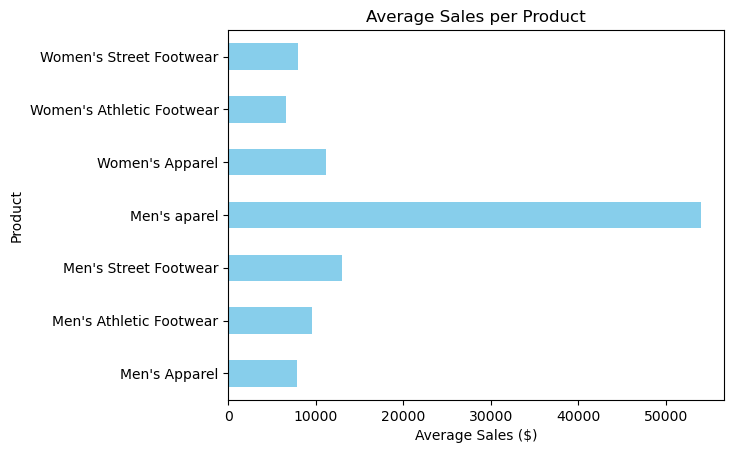

In [24]:
import matplotlib.pyplot as plt

average_sales_per_product.set_index('Product')['Average Sales'].plot(kind='barh', color='skyblue')
plt.title('Average Sales per Product')
plt.xlabel('Average Sales ($)')
plt.ylabel('Product')
plt.show()

### 4. What is the count of each product?


In [25]:
product_counts = data['Product'].value_counts().reset_index()
product_counts.columns = ['Product', 'Count']
display(product_counts)

,Product,Count
0,Men's Athletic Footwear,1615
1,Men's Apparel,1611
2,Men's Street Footwear,1610
3,Women's Apparel,1609
4,Women's Street Footwear,1608
5,Women's Athletic Footwear,1607
6,Men's aparel,1


### 5. What is the top product by total sales?


In [26]:
top_product = data.groupby('Product')['Total Sales'].sum().reset_index().sort_values(by='Total Sales', ascending=False).head(1)

top_product_styled = top_product.style.format({
    'Total Sales': '{:,.2f}$'
})

display(top_product_styled)

,Product,Total Sales
2,Men's Street Footwear,"20,882,669.00$"


### 6. What is the lowest-performing product by total sales?

In [27]:

lowest_product = data.groupby('Product')['Total Sales'].sum().reset_index().sort_values(by='Total Sales', ascending=True).head(1)

lowest_product_styled = lowest_product.style.format({
    'Total Sales': '{:,.2f}$'
})

display(lowest_product_styled)

,Product,Total Sales
3,Men's aparel,"54,000.00$"


## Time Analysis

### 7. How many products were sold each year?

In [28]:
products_per_year = data.groupby('year')['Units Sold'].sum().reset_index()
products_per_year.columns = ['Year', 'Total Units Sold']
products_per_year_styled = products_per_year.style.format({
    'Total Units Sold': '{:,.0f}'
})
display(products_per_year_styled)

,Year,Total Units Sold
0,2020,"470,674"
1,2021,"2,017,162"


### 8. How have total sales changed over the years?

In [29]:
sales_over_year = data.groupby('year')['Total Sales'].sum().reset_index()
sales_over_year.columns = ['Year', 'Total Sales']
sales_over_year_styled = sales_over_year.style.format({
    'Total Sales': '{:,.2f}$'
})
display(sales_over_year_styled)

,Year,Total Sales
0,2020,"18,675,850.00$"
1,2021,"71,819,092.00$"


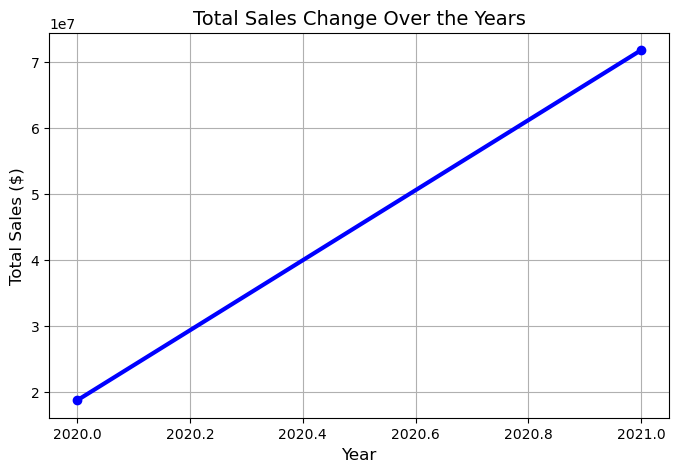

In [30]:
sales_over_years = data.groupby('year')['Total Sales'].sum()
plt.figure(figsize=(8, 5))
sales_over_years.plot(kind='line', marker='o', color='b', linewidth=3)

plt.title('Total Sales Change Over the Years', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True)

plt.show()

### 9. How do sales vary month over month?

In [31]:
sales_by_year_month = data.groupby(['year', 'month'])['Total Sales'].sum().reset_index()
sales_by_year_month.columns = ['Year', 'Month', 'Total Sales']
sales_by_year_month = sales_by_year_month.sort_values(by='Total Sales', ascending=False).reset_index(drop=True)
sales_by_year_month_styled = sales_by_year_month.style.format({
    'Total Sales': '{:,.2f}$'
})
display(sales_by_year_month_styled)

sales_by_month_overall = data.groupby('month')['Total Sales'].sum().reset_index()
sales_by_month_overall.columns = ['Month', 'Total Sales']
sales_by_month_overall = sales_by_month_overall.sort_values(by='Total Sales', ascending=False).reset_index(drop=True)
sales_by_month_overall_styled = sales_by_month_overall.style.format({
    'Total Sales': '{:,.2f}$'
})
display(sales_by_month_overall_styled)

,Year,Month,Total Sales
0,2021,7,"7,833,488.00$"
1,2021,12,"7,781,564.00$"
2,2021,8,"7,228,833.00$"
3,2021,6,"6,607,522.00$"
4,2021,5,"6,358,982.00$"
5,2021,11,"5,944,515.00$"
6,2021,9,"5,935,718.00$"
7,2021,1,"5,522,556.00$"
8,2021,10,"5,307,491.00$"
9,2021,4,"4,773,312.00$"


,Month,Total Sales
0,7,"9,548,092.00$"
1,8,"9,216,635.00$"
2,12,"8,584,218.00$"
3,5,"8,164,538.00$"
4,9,"7,766,164.00$"
5,6,"7,490,506.00$"
6,1,"7,363,937.00$"
7,4,"7,250,517.00$"
8,11,"6,806,744.00$"
9,10,"6,512,617.00$"


In [33]:
#pip install seaborn

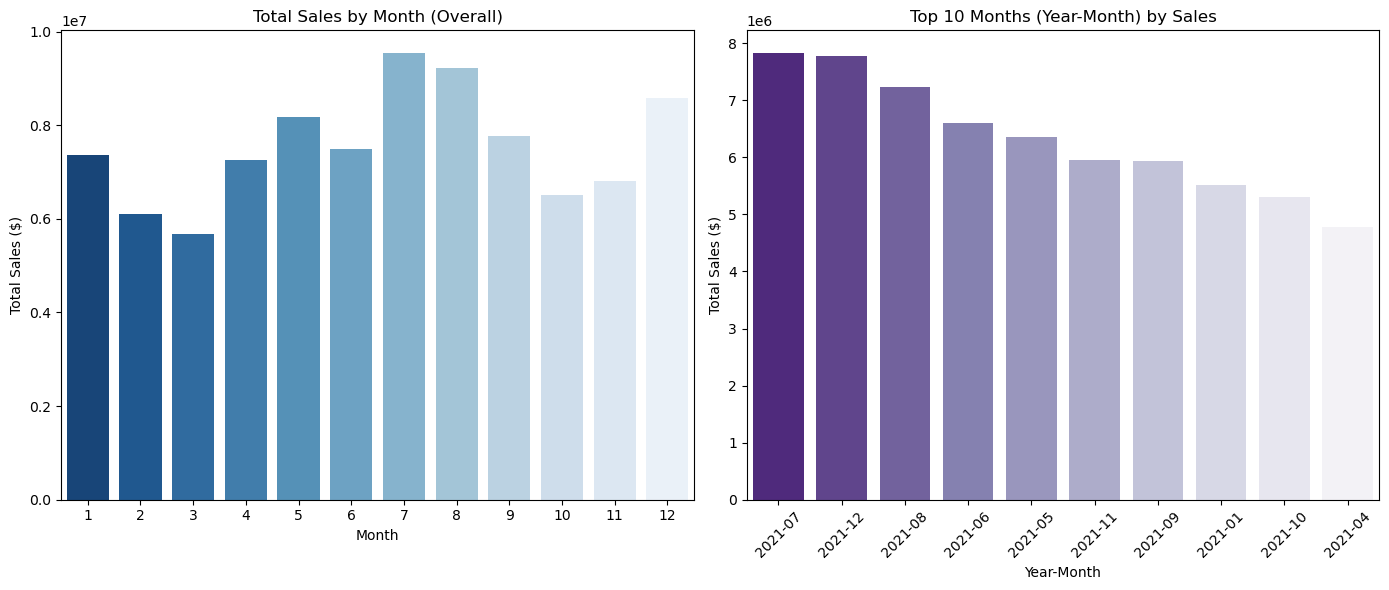

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sales_by_month_overall = data.groupby('month')['Total Sales'].sum().reset_index()
sales_by_month_overall = sales_by_month_overall.sort_values(by='Total Sales', ascending=False)

sns.barplot(data=sales_by_month_overall, x='month', y='Total Sales', palette='Blues_r')
plt.title('Total Sales by Month (Overall)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')


plt.subplot(1, 2, 2)

sales_by_year_month['Year-Month'] = sales_by_year_month['Year'].astype(str) + '-' + sales_by_year_month['Month'].astype(str).str.zfill(2)
top_10_ym = sales_by_year_month.head(10)

sns.barplot(data=top_10_ym, x='Year-Month', y='Total Sales', palette='Purples_r')
plt.title('Top 10 Months (Year-Month) by Sales')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Retailer Analysis

### 10. Which retailer has the highest total sales?


In [35]:
display(data.head())

,Retailer,Invoice Date,Region,State,city,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method,day,month,year
0,Foot Locker,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,60000,30000,In-store,1,1,2020
1,Foot Locker,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,50000,15000,In-store,2,1,2020
2,Foot Locker,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,40000,14000,In-store,3,1,2020
3,Foot Locker,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,38250,13388,In-store,4,1,2020
4,Foot Locker,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,54000,16200,In-store,5,1,2020


In [36]:
data['Retailer'] = data['Retailer'].str.strip().str.title()

top_retailers = data.groupby('Retailer')['Total Sales'].sum().reset_index().sort_values(by='Total Sales', ascending=False).reset_index(drop=True)
top_retailer_styled = top_retailers.style.format({
    'Total Sales': '{:,.2f}$'
})
display(top_retailer_styled)

,Retailer,Total Sales
0,West Gear,"24,312,990.00$"
1,Foot Locker,"22,262,278.00$"
2,Sports Direct,"18,247,156.00$"
3,Kohl'S,"10,211,506.00$"
4,Amazon,"7,769,912.00$"
5,Walmart,"7,691,100.00$"


### 11. Which retailer has the highest operating profit?


In [37]:
top_profit_retailer = data.groupby('Retailer')['Operating Profit'].sum().reset_index().sort_values(by='Operating Profit', ascending=False).reset_index(drop=True)
top_profit_retailer_styled = top_profit_retailer.style.format({
    'Operating Profit': '{:,.2f}$'
})
display(top_profit_retailer_styled)  

,Retailer,Operating Profit
0,West Gear,"8,571,819.00$"
1,Foot Locker,"8,148,962.00$"
2,Sports Direct,"7,433,383.00$"
3,Kohl'S,"3,681,153.00$"
4,Amazon,"2,881,885.00$"
5,Walmart,"2,654,877.00$"


## Product & Profit Analysis


### 12. What is the most profitable product?

In [38]:
ost_profitable_product = data.groupby('Product')['Operating Profit'].sum().reset_index().sort_values(by='Operating Profit', ascending=False).reset_index(drop=True)
ost_profitable_product_styled = ost_profitable_product.style.format({
    'Operating Profit': '{:,.2f}$'
})      
display(ost_profitable_product_styled)

,Product,Operating Profit
0,Men's Street Footwear,"8,280,294.00$"
1,Women's Apparel,"6,871,450.00$"
2,Men's Athletic Footwear,"5,232,784.00$"
3,Men's Apparel,"4,559,108.00$"
4,Women's Street Footwear,"4,509,653.00$"
5,Women's Athletic Footwear,"3,902,590.00$"
6,Men's aparel,"16,200.00$"


### 13. What is the average price per unit for each product?

In [39]:
avg_price_product = data.groupby('Product')['Price per Unit'].mean().reset_index().sort_values(by='Price per Unit', ascending=False).reset_index(drop=True)
avg_price_product_styled = avg_price_product.style.format({
    'Price per Unit': '{:,.2f}$'            
})      
display(avg_price_product_styled)  

,Product,Price per Unit
0,Men's aparel,60.00$
1,Women's Apparel,51.61$
2,Men's Apparel,50.35$
3,Men's Street Footwear,44.24$
4,Men's Athletic Footwear,43.78$
5,Women's Athletic Footwear,41.12$
6,Women's Street Footwear,40.25$


## Geographic Analysis

### 14. Which region has the highest total sales?

In [40]:
top_region = data.groupby('Region')['Total Sales'].sum().reset_index().sort_values(by='Total Sales', ascending=False).reset_index(drop=True)
top_region_styled = top_region.style.format({
    'Total Sales': '{:,.2f}$'
})
display(top_region_styled)

,Region,Total Sales
0,West,"26,919,128.00$"
1,Northeast,"18,983,237.00$"
2,Southeast,"16,317,146.00$"
3,South,"14,529,236.00$"
4,Midwest,"13,575,820.00$"
5,Unknown,"170,375.00$"


### 15. Which city contributes the most to total sales?

In [41]:
top_city = data.groupby('city')['Total Sales'].sum().reset_index().sort_values(by='Total Sales', ascending=False).reset_index(drop=True)
top_city_styled = top_city.style.format({
    'Total Sales': '{:,.2f}$'
})
display(top_city_styled)

,city,Total Sales
0,New York,"4,309,884.00$"
1,Charleston,"3,997,485.00$"
2,San Francisco,"3,453,924.00$"
3,Miami,"3,160,090.00$"
4,Portland,"3,054,564.00$"
5,Orlando,"2,768,290.00$"
6,Seattle,"2,633,075.00$"
7,Houston,"2,616,692.00$"
8,Los Angeles,"2,563,500.00$"
9,Albany,"2,442,784.00$"
